# Onset probes: what we did, and what the results look like

This notebook is a walkthrough for anyone who was not in the room while this
work happened (including future us). It has three jobs:

1. **Explain**, in plain language, what problem we are solving, how we built
   and labeled the data, and what the two probe designs and two training
   conditions are.
2. **Check** that every result file this notebook needs is actually on disk.
   If something is missing, the notebook prints the exact command to produce
   it, instead of quietly skipping it.
3. **Show** every plot needed to compare the results: no-LoRA vs LoRA, one
   probe per horizon (`probe_N`) vs one probe for all horizons
   (`multi_horizon`), across layers and across data splits.

Every plot is saved as both a PNG and a PDF file. The PDF path is printed
right under the plot, in case you want to drop it into a slide.

This notebook follows the same style as `notebooks/inspect_dataset.ipynb`
(same repo, same idea: explain + check + show), but it is about the
**probes** trained on top of the dataset, not the dataset itself.

## 1. The problem we are trying to solve

Sometimes a language model gets stuck while generating text. It starts
repeating the same words or the same short phrase over and over, forever,
until we cut it off. We call this **degeneration**.

We want to catch this *before* it fully happens. Not just "is the model
degenerating right now", but "is it about to start, in the next 5 tokens?
The next 20? The next 200?" (A token is roughly one word or one piece of a
word.)

We call the exact spot where a piece of text starts to go bad the
**onset**. A **rollout** is one full response the model generated for one
prompt (in our data, the model generated 10 rollouts per prompt).

To predict how close a given point in the text is to the onset, we train a
small model called a **probe**. A probe is tiny compared to the language
model - it just reads a snapshot of the language model's internal numbers
at one layer and outputs one prediction. It does not generate any text
itself.

## 2. How we decide "this rollout went bad", and exactly where

We only trust a rollout as a genuine degeneration case if it ran all the way
to our token limit (4096 tokens) without the model choosing to stop on its
own. If the model stopped by itself (it produced an end-of-text token), we
call the rollout **negative** - it never degenerated, so every position in
it gets a "not close to onset" label.

For a **positive** rollout (one that hit the 4096-token limit), we still
need to find *where inside the text* the repeating actually started. We do
this with a method called **LRS** (longest repeated substring): we scan the
whole rollout for the longest piece of text that repeats itself, and we mark
the first place that repeat starts as the onset position. This method also
catches the case where the "repeat" is a slowly growing number (like a model
stuck counting upward forever) - that counts as the same kind of repeat.

We only use positions up to and including the onset for training and
testing. Anything after the onset is already inside the degenerate part, so
it is not useful for predicting "when will this start".

For a horizon `N` (a number of tokens, e.g. 20) and a position `t` in the
text, the label is "yes, close" if the onset is at most `N` tokens further
along (`onset_position - t <= N`), otherwise "no, not close". We build this
label for five horizons: **5, 20, 50, 100, 200** tokens. Horizon 5 means
"about to degenerate right now"; horizon 200 means "somewhere in the next
200 tokens".

## 3. Two ways to build the probe

- **`probe_N`**: five completely separate probes, one trained per horizon
  (5, 20, 50, 100, 200). Each one only ever sees its own yes/no label and
  knows nothing about the other four.
- **`multi_horizon`**: one probe trained to predict all five horizons at
  once (it has five small outputs instead of one).

The horizons are naturally related: if a position is within 5 tokens of
onset, it is automatically also within 20, 50, 100 and 200 tokens of onset.
So a sane probe's predicted risk should never go *down* when we ask about a
bigger horizon. We check this directly later in the notebook (the "nesting"
check) - it is one way of asking whether `multi_horizon`'s single shared
model behaves more sensibly than five independent ones.

## 4. Two conditions: reading the model as-is, vs. letting it shift a little

- **No-LoRA (frozen model).** We never change the language model's weights.
  We record its internal numbers ("hidden states") once, for every layer,
  every token, every rollout, and save them to disk. Reading a saved number
  back is almost free, so we could afford to train and test a probe at
  **every one of the model's 33 layers** (the raw input embedding, plus all
  32 transformer blocks) - 33 layers x 5 `probe_N` horizons + 33
  `multi_horizon` probes = 198 probes total.
- **LoRA (lightly retrained model).** LoRA ("low-rank adaptation") is a
  cheap way to nudge a big model's behaviour without retraining all of it.
  Here we let the language model's own weights shift a small amount *while*
  we train the probe on top of it. This needs a real, live pass through the
  whole 8-billion-parameter model at every training step, so it is much more
  expensive than the no-LoRA condition. We only tried this as a **pilot**:
  one layer (layer 16, chosen because it did well in the no-LoRA sweep), one
  pass over the training data (one epoch), six probes total (the five
  `probe_N` ones plus the one `multi_horizon` one).

The question this notebook tries to answer for the LoRA condition is simple:
**does letting the model shift a little bit, together with the probe, give
better predictions than just reading its frozen activations?**

## 4.1 Exactly how each condition was trained

This section spells out the exact numbers behind "we trained a probe": the
loss function, how batches were built, and (for LoRA) exactly which part of
the language model we let move. Nothing here is a choice made for this
notebook - it is what the two training scripts actually did
(`scripts/train_onset_probes.py` for no-LoRA, `scripts/train_onset_lora_pilot.py`
for LoRA).

### No-LoRA training

- **Probe shape.** A single linear layer, nothing fancier: input is one
  token's hidden state (4096 numbers) at the chosen layer, output is either 1
  number (`probe_N`, one horizon) or 5 numbers (`multi_horizon`, all horizons
  at once). No hidden layer, no non-linearity.
- **Loss.** Binary cross-entropy (the standard "yes/no" loss) between the
  probe's prediction and the 0/1 onset label, computed separately per
  horizon. Each horizon's loss is scaled by a "pos_weight" - a number that
  makes rare positive examples count for more, computed from the true,
  un-subsampled fraction of positive tokens for that horizon in the training
  data. Horizon 5 (the rarest positive label) ends up weighted far more
  heavily than horizon 200. For `multi_horizon`, the five horizons' losses
  are added together as a weighted sum (same pos_weight-derived numbers,
  rescaled to add up to 5) - one shared model, one combined loss, one
  optimizer step.
- **Optimizer.** Adam, learning rate 0.001. Six models are trained side by
  side (5 `probe_N` heads + 1 `multi_horizon` head), each with its own
  optimizer, so none of them affects another's weights.
- **How batches were built.** Every rollout's hidden states are read from
  disk once, up front, straight into memory - not re-read every epoch, since
  re-reading identical numbers 30 times over would have made this take 30x
  longer for no benefit. Training batches are then just 4096 individual
  *token positions*, shuffled together (not 4096 rollouts - one rollout can
  contribute hundreds of token positions).
- **Training length.** A fixed **30 epochs** (30 full passes over the
  training tokens). No early stopping, no best-checkpoint selection: there is
  no rule that watches validation loss and stops early or picks the best
  point along the way. We simply always run the full 30 epochs and evaluate
  whatever the model looks like at the end.
- **Handling how rare "positive" is.** Two more knobs, on top of the
  pos_weight above: (1) within one negative (never-degenerates) rollout,
  only up to 32 of its (possibly thousands of) token positions are kept per
  epoch, chosen at random; (2) across rollouts, every positive rollout is
  used every epoch, but negative rollouts are subsampled down to 4x the
  number of positive rollouts (instead of the raw ~45x imbalance in the raw
  corpus). Both of these only change what the *training* data looks like -
  the validation split used for every score in this notebook keeps every
  negative rollout, untouched by this subsampling.

### LoRA training

- **What LoRA actually changes.** LoRA adds a small number of extra,
  trainable weights alongside the language model's own (frozen) weights, in
  specific places, and only lets those extra weights move - the model's
  original 8 billion weights never change. Here, LoRA is attached to **every
  layer from 0 up to and including the probed layer - layers 0 through 16,
  not the full 32-layer model.** The reasoning: only the layers whose output
  the probe actually reads can affect the probe's input, so there is no
  point letting later layers move too. Within each of those 17 layers, LoRA
  touches all four attention projections (query/key/value/output) and all
  three feed-forward projections (gate/up/down) - effectively the entire
  computation of those layers, just adjusted through a small trainable
  add-on rather than retraining the full weight matrices directly. Rank 16,
  alpha 32, dropout 0.05 (standard LoRA settings; rank controls how many
  extra numbers get added per weight matrix - a bigger rank means more
  capacity to change behaviour, and more trainable parameters).
- **How small is "small"?** 21.2 million trainable parameters in total (the
  LoRA add-ons, the probe head, and one LayerNorm placed just before the
  probe head) out of the model's 8.07 billion - **0.26%**. The remaining
  99.74% of the model's weights never move during this training run.
- **Probe head.** Same shape as no-LoRA (linear, 1 or 5 outputs), but it runs
  in float32 (higher numerical precision) even though the language model
  itself runs in bfloat16 (lower precision, faster - standard for a model
  this size). A LayerNorm (a small normalization step) sits right before the
  probe head, also in float32. The probe head is tiny, so this extra
  precision costs almost nothing and keeps its training numerically stable.
- **Loss.** Same shape as no-LoRA - per-horizon binary cross-entropy with the
  same pos_weight idea, summed with the same renormalized weights for
  `multi_horizon`. The training script also logs a language-modeling loss
  ("lm_loss", how well the model still predicts the next word) for visibility,
  but it is never actually added into the loss being optimized here
  (its weight, "lambda_lm", is set to 0) - only the onset-prediction loss
  drives the weight updates. The real difference from no-LoRA is that
  computing this loss needs an actual forward pass through the whole
  8-billion-parameter model every step, since the model's own weights are
  moving and cached hidden states from before training started are no longer
  valid - this is the main reason the LoRA condition is far more expensive
  than no-LoRA, where the numbers are simply read off disk.
- **Learning rates.** Three separate parameter groups, three learning rates:
  the probe head and the LoRA add-ons both use 0.0001; the LayerNorm
  ("other") uses 0.00005 - all smaller than no-LoRA's 0.001, since here the
  gradient is also flowing back into the language model's own numbers
  (through LoRA), which is far more sensitive to a large step size than a
  standalone probe reading frozen, unchanging inputs.
- **How batches were built.** One rollout per GPU step, accumulated over 16
  steps before every actual weight update (an "effective" batch of 16
  rollouts per update). One rollout at a time keeps memory manageable for an
  8-billion-parameter model with gradients flowing through it; accumulation
  recovers a larger effective batch size without needing more memory. Each
  rollout is truncated/padded to at most 4608 tokens total (of which up to
  4096 can be the model's own generated text, matching the 4096-token
  generation limit used everywhere else in this project). Gradient
  checkpointing (a memory-saving trick that recomputes some values during the
  backward pass instead of storing them) is turned on, again to fit in
  memory.
- **Training length.** Exactly **one pass (one epoch)** over the pilot's
  training rollouts - for the `multi_horizon` run, that is 2,712 rollouts
  (605 of them positive), giving 170 total optimizer steps. No early
  stopping and no best-checkpoint selection here either: the only checkpoint
  ever saved is whatever the model looks like after that single epoch
  finishes.
- **Which rollouts were used at all.** Training on every rollout in the
  corpus would have been far too slow for a first pilot. Instead, every
  positive rollout is kept, plus a "matched" sample of negative rollouts
  (about 2,500 total across train+val, split proportionally between them,
  and picked to match the original mix of prompt topics rather than being a
  totally random sample) - see `select_lora_pilot_rollouts` in
  `degeneration_probe/data/onset_lora_dataset.py`.

In [1]:
import json
import os
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from degeneration_probe.dataset_gen import paths
from degeneration_probe.dataset_gen.config import DatasetGenConfig
from degeneration_probe.dataset_gen.onset_labels import DEFAULT_HORIZONS
from degeneration_probe.data.onset_dataset import build_rollout_index

pd.set_option("display.max_colwidth", 120)
warnings.filterwarnings("ignore", category=FutureWarning)

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATASET_CONFIG_PATH = REPO_ROOT / "configs" / "dataset" / "degeneration-dataset-apertus-8b-instruct.yaml"
config = DatasetGenConfig.from_yaml(DATASET_CONFIG_PATH)
DATASET_ROOT = paths.dataset_root(config)
ONSET_PROBES_ROOT = DATASET_ROOT / "probes" / "onset"
LOCAL_PROBES_DIR = Path(f"/capstor/scratch/cscs/{os.environ['USER']}/degeneration-probe/probes")

HORIZONS = list(DEFAULT_HORIZONS)  # [5, 20, 50, 100, 200]
SPLITS = ["val", "test_indomain", "test_heldout_domains"]
ALL_LAYERS = list(range(33))
LORA_LAYER = 16  # the only layer the LoRA pilot covers
LORA_PROBE_IDS = {
    "multi_horizon": "onset_multi_horizon_lora_pilot_layer16",
    5: "onset_probe_5_lora_pilot_layer16",
    20: "onset_probe_20_lora_pilot_layer16",
    50: "onset_probe_50_lora_pilot_layer16",
    100: "onset_probe_100_lora_pilot_layer16",
    200: "onset_probe_200_lora_pilot_layer16",
}

FIGURES_DIR = REPO_ROOT / "notebooks" / "figures" / "onset_probes"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
# NOT under FIGURES_DIR -- notebooks/figures/ is gitignored (generated plots, not
# source). These two small CSVs are extracted once from SLURM job logs (see Section
# 10.1) and need to actually survive in git, since the logs themselves might not.
TRAINING_CURVES_DIR = REPO_ROOT / "notebooks" / "training_curves"

# Save a plot as both PNG and PDF, and print where the PDF landed.
def save_fig(fig, name, subdir=""):
    out_dir = FIGURES_DIR / subdir if subdir else FIGURES_DIR
    out_dir.mkdir(parents=True, exist_ok=True)
    png_path = out_dir / f"{name}.png"
    pdf_path = out_dir / f"{name}.pdf"
    fig.savefig(png_path, dpi=150, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved: {png_path}")
    print(f"Saved (PDF): {pdf_path}")
    return png_path, pdf_path


# Colors: picked once, used everywhere, so the same thing always has the same
# color across every plot in this notebook.
#   - condition (no-LoRA vs LoRA) is encoded by hue family (blue vs orange/red)
#   - design (probe_N vs multi_horizon) is encoded by shade within that family
COLOR_NOLORA_PROBE_N = "#0072B2"       # dark blue
COLOR_NOLORA_MULTI = "#56B4E9"         # light blue
COLOR_LORA_PROBE_N = "#D55E00"         # dark orange/red
COLOR_LORA_MULTI = "#E69F00"           # light orange
CONDITION_DESIGN_COLORS = {
    ("no-LoRA", "probe_N"): COLOR_NOLORA_PROBE_N,
    ("no-LoRA", "multi_horizon"): COLOR_NOLORA_MULTI,
    ("LoRA", "probe_N"): COLOR_LORA_PROBE_N,
    ("LoRA", "multi_horizon"): COLOR_LORA_MULTI,
}
# One consistent color per horizon, light (short horizon) -> dark (long horizon),
# reused in every plot that breaks a result down by horizon.
HORIZON_CMAP = mpl.colormaps["viridis"]
HORIZON_COLORS = {h: HORIZON_CMAP(i / (len(HORIZONS) - 1)) for i, h in enumerate(HORIZONS)}

print(f"Dataset root        : {DATASET_ROOT}")
print(f"No-LoRA probes root : {ONSET_PROBES_ROOT}")
print(f"LoRA probes root    : {LOCAL_PROBES_DIR}")
print(f"Figures dir          : {FIGURES_DIR}")
print(f"Training curves dir  : {TRAINING_CURVES_DIR}")

W0713 19:06:16.387000 215220 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


W0713 19:06:16.544000 215220 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


Dataset root        : /capstor/store/cscs/swissai/infra01/users/mdenegri/degeneration-probe/degeneration-dataset-apertus-8b-instruct
No-LoRA probes root : /capstor/store/cscs/swissai/infra01/users/mdenegri/degeneration-probe/degeneration-dataset-apertus-8b-instruct/probes/onset
LoRA probes root    : /capstor/scratch/cscs/mdenegri/degeneration-probe/probes
Figures dir          : /iopsstor/scratch/cscs/mdenegri/degeneration-probe/notebooks/figures/onset_probes
Training curves dir  : /iopsstor/scratch/cscs/mdenegri/degeneration-probe/notebooks/training_curves


## 5. Checking what results actually exist on disk

Before we look at any numbers, we check that every file we need is actually
there. This covers both conditions:

- **No-LoRA**: for every one of the 33 layers, do we have the trained probes,
  and the evaluation files (`eval_metrics.parquet`, `agreement.parquet`,
  `nesting.parquet`) that score them on `val` / `test_indomain` /
  `test_heldout_domains`?
- **LoRA**: for each of the 6 pilot checkpoints, do we have the training
  run's own `val`-split numbers (`evaluation_results.json`), and the extra
  `test_indomain` / `test_heldout_domains` numbers this notebook needed
  built specially (`eval_extra_splits.parquet`, since the training script
  itself only ever scores `val`)?

If anything is missing, we print the command that produces it instead of
silently skipping it.

In [2]:
# --- No-LoRA completeness: all 33 layers, all expected files ---
NOLORA_FILES = ["eval_metrics.parquet", "agreement.parquet", "nesting.parquet", "eval_val.parquet"]
NOLORA_HEADS = ["multi_horizon"] + [f"probe_{h}" for h in HORIZONS]

missing_layers = []
missing_files = {f: [] for f in NOLORA_FILES}
missing_heads = {h: [] for h in NOLORA_HEADS}
for layer in ALL_LAYERS:
    layer_dir = ONSET_PROBES_ROOT / f"layer_{layer:02d}"
    if not layer_dir.exists():
        missing_layers.append(layer)
        continue
    for f in NOLORA_FILES:
        if not (layer_dir / f).exists():
            missing_files[f].append(layer)
    for h in NOLORA_HEADS:
        if not (layer_dir / h / "probe_head.bin").exists():
            missing_heads[h].append(layer)

print(f"No-LoRA: {len(ALL_LAYERS) - len(missing_layers)}/{len(ALL_LAYERS)} layer directories present.")
if missing_layers:
    print(f"  MISSING layer dirs: {missing_layers}")
    print(f"  -> to build: PYTHONPATH=$REPO python scripts/train_onset_probes.py --layer <N>  (for each missing N)")
for f in NOLORA_FILES:
    status = "OK" if not missing_files[f] else f"MISSING for layers {missing_files[f]}"
    print(f"  {f:<20s}: {status}")
    if missing_files[f] and "eval_" in f and f != "eval_val.parquet":
        print(f"    -> to build: PYTHONPATH=$REPO python scripts/evaluate_onset_probes.py --layer <N>")
for h in NOLORA_HEADS:
    if missing_heads[h]:
        print(f"  head {h:<15s}: MISSING for layers {missing_heads[h]}")

No-LoRA: 33/33 layer directories present.
  eval_metrics.parquet: OK
  agreement.parquet   : OK
  nesting.parquet     : OK
  eval_val.parquet    : OK


In [3]:
# --- LoRA completeness: the 6 pilot checkpoints ---
lora_rows = []
for design, probe_id in LORA_PROBE_IDS.items():
    probe_dir = LOCAL_PROBES_DIR / probe_id
    has_checkpoint = (probe_dir / "adapter_model.safetensors").exists() and (probe_dir / "probe_head.bin").exists()
    has_val = (probe_dir / "evaluation_results.json").exists()
    has_extra = (probe_dir / "eval_extra_splits.parquet").exists()
    lora_rows.append({
        "design": design, "probe_id": probe_id,
        "checkpoint_present": has_checkpoint, "val_eval_present": has_val,
        "test_splits_eval_present": has_extra,
    })
lora_status_df = pd.DataFrame(lora_rows)
display(lora_status_df)

for row in lora_rows:
    if not row["checkpoint_present"]:
        print(f"MISSING checkpoint for {row['probe_id']}.")
        print(f"  -> to build: sbatch cluster/train_onset_lora_pilot.sbatch  (or train_onset_lora_full.sbatch for a single horizon / all horizons)")
    if row["checkpoint_present"] and not row["test_splits_eval_present"]:
        print(f"MISSING test_indomain/test_heldout_domains eval for {row['probe_id']}.")
        print(f"  -> to build: sbatch cluster/evaluate_onset_lora_probes.sbatch {row['probe_id']}")

,design,probe_id,checkpoint_present,val_eval_present,test_splits_eval_present
0,multi_horizon,onset_multi_horizon_lora_pilot_layer16,True,True,True
1,5,onset_probe_5_lora_pilot_layer16,True,True,True
2,20,onset_probe_20_lora_pilot_layer16,True,True,True
3,50,onset_probe_50_lora_pilot_layer16,True,True,True
4,100,onset_probe_100_lora_pilot_layer16,True,True,True
5,200,onset_probe_200_lora_pilot_layer16,True,True,True


## 6. How much data are we working with

A quick look at the corpus before diving into probe results: how many
rollouts per split, and how rare "positive" (degenerating) rollouts really
are. This matters for reading every AUC number later - with only 11
positive rollouts in `test_heldout_domains`, for example, any number from
that split is a rough estimate, not a precise one.

,n_rollouts,n_positive,positive_rate_pct
split,,,
train,16800,605,3.60
val,3600,113,3.14
test_indomain,3600,133,3.69
test_heldout_domains,6300,11,0.17


Saved: /iopsstor/scratch/cscs/mdenegri/degeneration-probe/notebooks/figures/onset_probes/01_dataset_overview.png
Saved (PDF): /iopsstor/scratch/cscs/mdenegri/degeneration-probe/notebooks/figures/onset_probes/01_dataset_overview.pdf


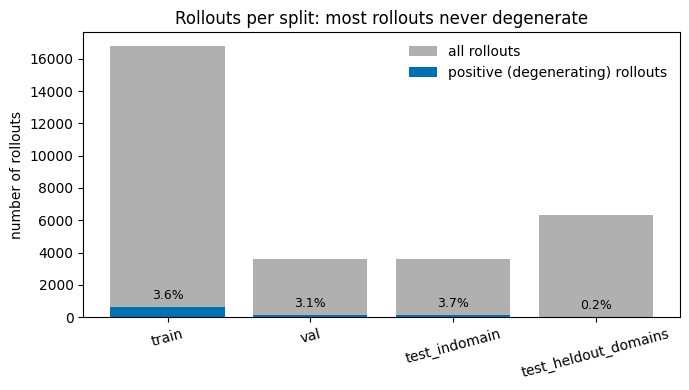

In [4]:
onset_labels_df = pd.read_parquet(paths.onset_labels_path(config))
overview = (
    onset_labels_df.groupby("split")["is_positive"]
    .agg(n_rollouts="count", n_positive="sum")
    .reindex(["train", "val", "test_indomain", "test_heldout_domains"])
)
overview["positive_rate_pct"] = (100 * overview["n_positive"] / overview["n_rollouts"]).round(2)
display(overview)

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(overview))
ax.bar(x, overview["n_rollouts"], color="#B0B0B0", label="all rollouts")
ax.bar(x, overview["n_positive"], color=COLOR_NOLORA_PROBE_N, label="positive (degenerating) rollouts")
ax.set_xticks(x)
ax.set_xticklabels(overview.index, rotation=15)
ax.set_ylabel("number of rollouts")
ax.set_title("Rollouts per split: most rollouts never degenerate")
ax.legend(frameon=False)
for i, (n_pos, rate) in enumerate(zip(overview["n_positive"], overview["positive_rate_pct"])):
    ax.annotate(f"{rate:.1f}%", (i, n_pos), textcoords="offset points", xytext=(0, 6), ha="center", fontsize=9)
plt.tight_layout()
save_fig(fig, "01_dataset_overview")
plt.show()

## 7. A first, quick look: which layers looked promising?

Before training real probes at every layer, we ran a much cheaper check: a
simple logistic regression (a small, classic statistics model, not a neural
network) fit directly on one hidden-state snapshot per example. This is not
the final result - it is a fast, rough compass that told us where to look
more carefully, and it is what we used to pick layer 16 for the LoRA pilot.

Darker means a higher AUC (explained below), i.e. an easier layer/horizon
combination to predict.

Saved: /iopsstor/scratch/cscs/mdenegri/degeneration-probe/notebooks/figures/onset_probes/02_layer_sweep_heatmap.png
Saved (PDF): /iopsstor/scratch/cscs/mdenegri/degeneration-probe/notebooks/figures/onset_probes/02_layer_sweep_heatmap.pdf


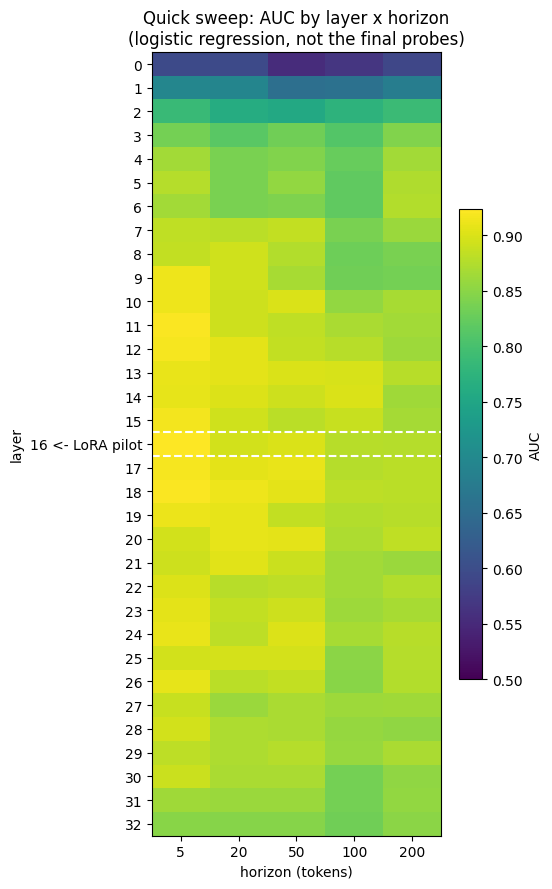

In [5]:
sweep_df = pd.read_parquet(DATASET_ROOT / "onset_labels" / "layer_sweep_auc.parquet")
pivot = sweep_df.pivot(index="layer", columns="horizon", values="auc").reindex(columns=HORIZONS)

fig, ax = plt.subplots(figsize=(5.5, 9))
im = ax.imshow(pivot.values, aspect="auto", cmap="viridis", vmin=0.5, vmax=pivot.values.max())
ax.set_xticks(range(len(HORIZONS)))
ax.set_xticklabels(HORIZONS)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("horizon (tokens)")
ax.set_ylabel("layer")
ax.set_title("Quick sweep: AUC by layer x horizon\n(logistic regression, not the final probes)")
ax.axhline(LORA_LAYER - 0.5, color="white", linewidth=1.5, linestyle="--")
ax.axhline(LORA_LAYER + 0.5, color="white", linewidth=1.5, linestyle="--")
ax.set_yticks(list(pivot.index))
ax.set_yticklabels([f"{l} <- LoRA pilot" if l == LORA_LAYER else str(l) for l in pivot.index])
cbar = fig.colorbar(im, ax=ax, shrink=0.6)
cbar.set_label("AUC")
plt.tight_layout()
save_fig(fig, "02_layer_sweep_heatmap")
plt.show()

## 8. The real no-LoRA results: probe performance per layer, per horizon

Now the real numbers: probes actually trained (not the quick sweep above)
and scored on the `val` split, at every layer, for both designs.

**What AUC means, in plain words:** take one position that really is close
to onset and one that is not, both picked at random. AUC is the chance the
probe gives the "close to onset" one a higher risk score. 0.5 means the
probe is guessing (a coin flip). 1.0 means it always gets the order right.
Higher is better.

In [6]:
def load_all_eval_metrics():
    frames = []
    for layer in ALL_LAYERS:
        p = ONSET_PROBES_ROOT / f"layer_{layer:02d}" / "eval_metrics.parquet"
        if p.exists():
            frames.append(pd.read_parquet(p))
    return pd.concat(frames, ignore_index=True)


eval_metrics_df = load_all_eval_metrics()
print(f"Loaded eval_metrics.parquet for {eval_metrics_df['layer'].nunique()} layers.")
display(eval_metrics_df.head())

Loaded eval_metrics.parquet for 33 layers.


,layer,split,horizon,design,auc,ap,brier,n,n_pos
0,0,val,5,probe_N,0.593539,0.005259,0.762932,206725,645
1,0,val,5,multi_horizon,0.594099,0.005200,0.762957,206725,645
2,0,val,20,probe_N,0.573224,0.013998,0.807582,206725,2222
3,0,val,20,multi_horizon,0.573061,0.013978,0.807569,206725,2222
4,0,val,50,probe_N,0.571923,0.032535,0.814261,206725,5297


Saved: /iopsstor/scratch/cscs/mdenegri/degeneration-probe/notebooks/figures/onset_probes/03_noLoRA_auc_vs_layer.png
Saved (PDF): /iopsstor/scratch/cscs/mdenegri/degeneration-probe/notebooks/figures/onset_probes/03_noLoRA_auc_vs_layer.pdf


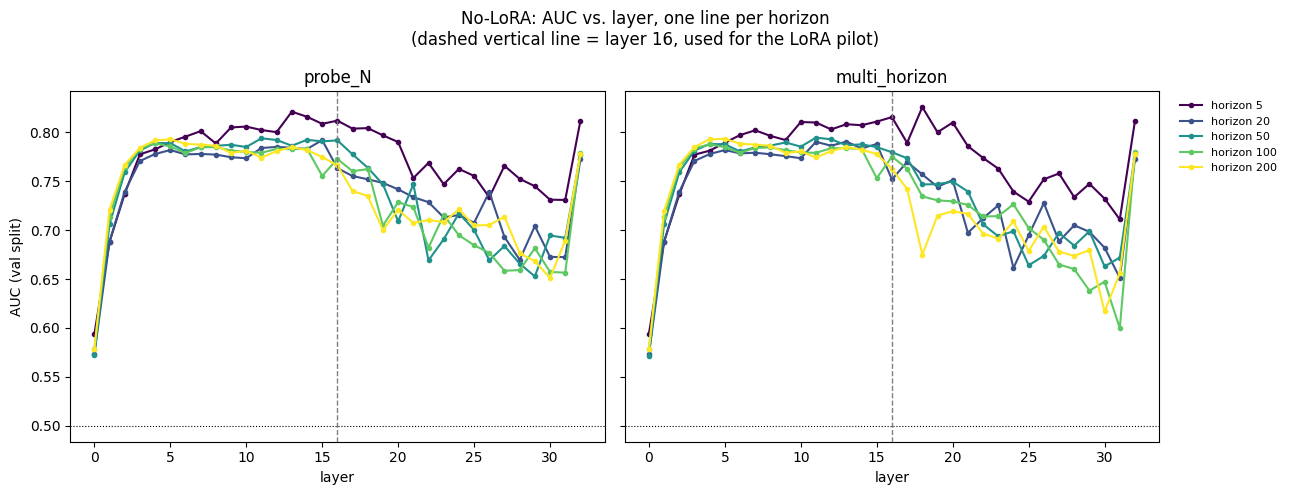

In [7]:
val_df = eval_metrics_df[eval_metrics_df["split"] == "val"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, design in zip(axes, ["probe_N", "multi_horizon"]):
    sub = val_df[val_df["design"] == design]
    for h in HORIZONS:
        h_sub = sub[sub["horizon"] == h].sort_values("layer")
        ax.plot(h_sub["layer"], h_sub["auc"], color=HORIZON_COLORS[h], marker="o", markersize=3, linewidth=1.5, label=f"horizon {h}")
    ax.axvline(LORA_LAYER, color="gray", linewidth=1, linestyle="--")
    ax.axhline(0.5, color="black", linewidth=0.8, linestyle=":")
    ax.set_title(design)
    ax.set_xlabel("layer")
axes[0].set_ylabel("AUC (val split)")
axes[1].legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=8)
fig.suptitle("No-LoRA: AUC vs. layer, one line per horizon\n(dashed vertical line = layer 16, used for the LoRA pilot)")
plt.tight_layout()
save_fig(fig, "03_noLoRA_auc_vs_layer")
plt.show()

In [8]:
# Best layer per horizon (multi_horizon design, val split) -- and where layer 16 ranks.
best_rows = []
for h in HORIZONS:
    sub = val_df[(val_df["design"] == "multi_horizon") & (val_df["horizon"] == h)].sort_values("auc", ascending=False).reset_index(drop=True)
    layer16_rank = int(sub.index[sub["layer"] == LORA_LAYER][0]) + 1
    layer16_auc = float(sub.loc[sub["layer"] == LORA_LAYER, "auc"].iloc[0])
    best_rows.append({
        "horizon": h, "best_layer": int(sub.iloc[0]["layer"]), "best_auc": sub.iloc[0]["auc"],
        "layer16_auc": layer16_auc, "layer16_rank_out_of_33": layer16_rank,
    })
best_layer_df = pd.DataFrame(best_rows)
display(best_layer_df)
print("Layer 16 is a good, but not always the single best, layer -- results below use layer 16")
print("throughout so the no-LoRA numbers are directly comparable to the LoRA pilot, which only covers that layer.")

,horizon,best_layer,best_auc,layer16_auc,layer16_rank_out_of_33
0,5,18,0.825918,0.815643,2
1,20,13,0.790573,0.751864,17
2,50,11,0.794656,0.779756,14
3,100,4,0.787942,0.775170,14
4,200,5,0.793348,0.762690,16


Layer 16 is a good, but not always the single best, layer -- results below use layer 16
throughout so the no-LoRA numbers are directly comparable to the LoRA pilot, which only covers that layer.


## 9. `probe_N` vs `multi_horizon`, and how well results hold up on unseen splits

`val` is the split we used to pick things like the layer above. The real
test is whether performance holds up on data the probes never influenced
any decision on: `test_indomain` (same kind of prompts as training, held-out
prompts) and `test_heldout_domains` (entirely different prompt topics, and
only 11 positive rollouts in total - treat this split as a rough signal,
not a precise number).

Saved: /iopsstor/scratch/cscs/mdenegri/degeneration-probe/notebooks/figures/onset_probes/04_noLoRA_probeN_vs_multihorizon_by_split.png
Saved (PDF): /iopsstor/scratch/cscs/mdenegri/degeneration-probe/notebooks/figures/onset_probes/04_noLoRA_probeN_vs_multihorizon_by_split.pdf


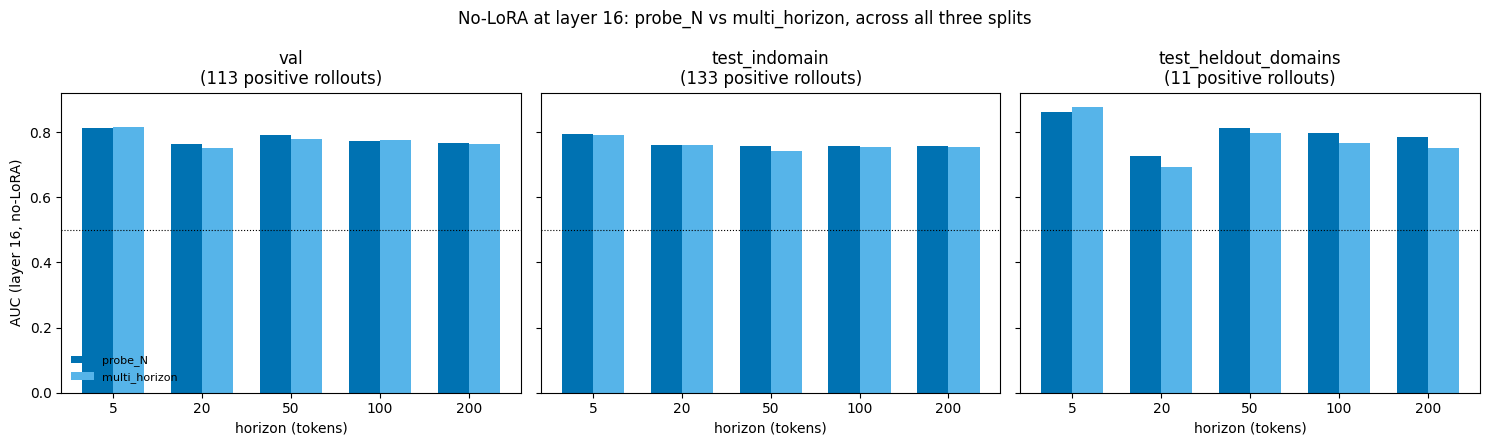

In [9]:
layer16_df = eval_metrics_df[eval_metrics_df["layer"] == LORA_LAYER]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
bar_width = 0.35
for ax, split in zip(axes, SPLITS):
    sub = layer16_df[layer16_df["split"] == split]
    x = np.arange(len(HORIZONS))
    for i, design in enumerate(["probe_N", "multi_horizon"]):
        vals = [sub[(sub["design"] == design) & (sub["horizon"] == h)]["auc"].iloc[0] for h in HORIZONS]
        color = COLOR_NOLORA_PROBE_N if design == "probe_N" else COLOR_NOLORA_MULTI
        ax.bar(x + (i - 0.5) * bar_width, vals, width=bar_width, color=color, label=design)
    n_pos = int(onset_labels_df[onset_labels_df["split"] == split]["is_positive"].sum())
    ax.set_xticks(x)
    ax.set_xticklabels(HORIZONS)
    ax.axhline(0.5, color="black", linewidth=0.8, linestyle=":")
    ax.set_title(f"{split}\n({n_pos} positive rollouts)")
    ax.set_xlabel("horizon (tokens)")
axes[0].set_ylabel("AUC (layer 16, no-LoRA)")
axes[0].legend(frameon=False, loc="lower left", fontsize=8)
fig.suptitle("No-LoRA at layer 16: probe_N vs multi_horizon, across all three splits")
plt.tight_layout()
save_fig(fig, "04_noLoRA_probeN_vs_multihorizon_by_split")
plt.show()

## 10. Does `multi_horizon` behave more sensibly than five separate probes?

As explained in Section 3, being close to onset at a short horizon (5
tokens) automatically means you are also close at every longer horizon (20,
50, 100, 200). A well-behaved probe's average predicted risk should never
go down as the horizon grows, and individual tokens should rarely have a
smaller-horizon prediction that is higher than a larger-horizon one for the
same position ("violations").

Since `multi_horizon` is one model with five outputs trained together, nothing
forces this ordering directly, but the shared training might encourage it.
`probe_N`'s five probes are completely independent, so they have no reason
to agree with each other at all. We check which one actually behaves better.

Saved: /iopsstor/scratch/cscs/mdenegri/degeneration-probe/notebooks/figures/onset_probes/05_noLoRA_nesting_violations.png
Saved (PDF): /iopsstor/scratch/cscs/mdenegri/degeneration-probe/notebooks/figures/onset_probes/05_noLoRA_nesting_violations.pdf


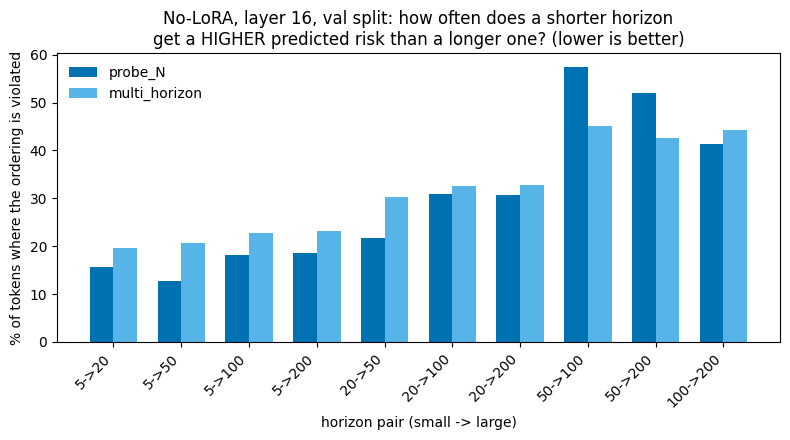

In [10]:
def load_all_nesting():
    frames = []
    for layer in ALL_LAYERS:
        p = ONSET_PROBES_ROOT / f"layer_{layer:02d}" / "nesting.parquet"
        if p.exists():
            frames.append(pd.read_parquet(p))
    return pd.concat(frames, ignore_index=True)


nesting_df = load_all_nesting()
layer16_nesting = nesting_df[(nesting_df["layer"] == LORA_LAYER) & (nesting_df["split"] == "val")]

fig, ax = plt.subplots(figsize=(8, 4.5))
pairs = layer16_nesting.sort_values(["horizon_small", "horizon_large"])[["horizon_small", "horizon_large"]].drop_duplicates()
pair_labels = [f"{s}->{l}" for s, l in pairs.itertuples(index=False)]
x = np.arange(len(pair_labels))
bar_width = 0.35
for i, design in enumerate(["probe_N", "multi_horizon"]):
    sub = layer16_nesting[layer16_nesting["design"] == design].sort_values(["horizon_small", "horizon_large"])
    color = COLOR_NOLORA_PROBE_N if design == "probe_N" else COLOR_NOLORA_MULTI
    ax.bar(x + (i - 0.5) * bar_width, sub["pairwise_violation_rate"].values * 100, width=bar_width, color=color, label=design)
ax.set_xticks(x)
ax.set_xticklabels(pair_labels, rotation=45, ha="right")
ax.set_ylabel("% of tokens where the ordering is violated")
ax.set_xlabel("horizon pair (small -> large)")
ax.set_title("No-LoRA, layer 16, val split: how often does a shorter horizon\nget a HIGHER predicted risk than a longer one? (lower is better)")
ax.legend(frameon=False)
plt.tight_layout()
save_fig(fig, "05_noLoRA_nesting_violations")
plt.show()

## 10.1 What did learning actually look like? (training and validation curves)

Everything above is the *final* score of a trained probe. This section
looks at the training process itself: did the loss actually go down while
training was running, and (for LoRA, where we have it) did the validation
score improve over the course of the one epoch?

A quick reminder of what a training curve tells you: if the loss keeps going
down on the data the model is training on, the model is fitting that data.
Whether that is *good* depends on what happens on held-out data (validation)
at the same time - if training loss goes down but validation score does not
improve (or gets worse), that is a sign of overfitting (memorizing the
specific training examples rather than learning something general).

**A caveat before the plots**: none of this is saved as a proper metrics
file - it only ever existed as lines printed to each job's SLURM log file
(`cluster/log/*.log`), which is not tracked in this repository and is not
guaranteed to stick around. We parsed those logs once and saved the numbers
into two small CSV files under `notebooks/training_curves/` (a plain,
git-tracked folder - deliberately not under `notebooks/figures/`, since that
whole directory is gitignored) so this section keeps working even if the
original job logs are ever cleaned up. If you retrain, this section will
only reflect the runs that were parsed at the time this notebook was built -
see the code cells for exactly which job logs were used.

Saved: /iopsstor/scratch/cscs/mdenegri/degeneration-probe/notebooks/figures/onset_probes/05a_training_curve_nolora_layer16.png
Saved (PDF): /iopsstor/scratch/cscs/mdenegri/degeneration-probe/notebooks/figures/onset_probes/05a_training_curve_nolora_layer16.pdf


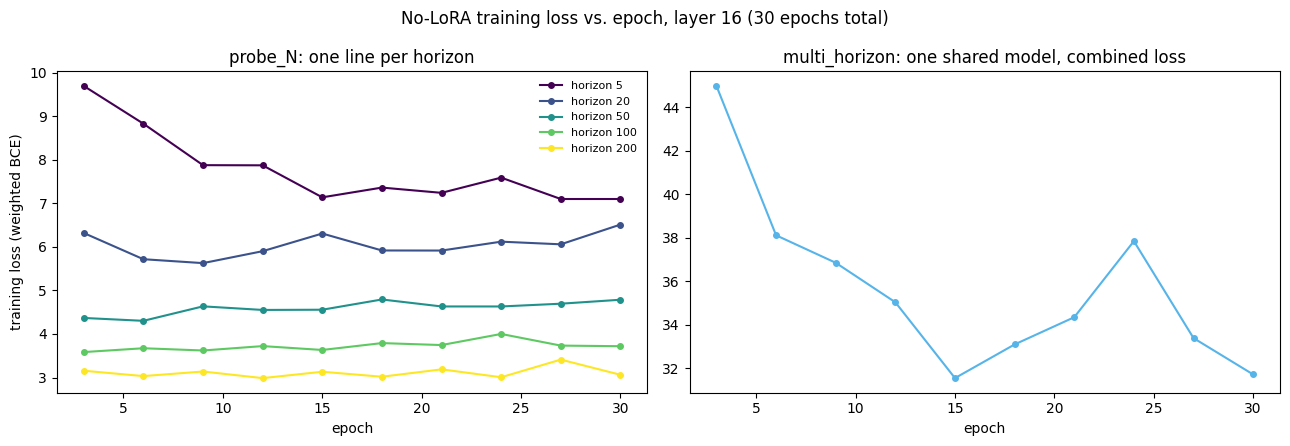

In [11]:
# --- No-LoRA training loss, layer 16 (the layer the LoRA pilot also uses) ---
nolora_curve_path = TRAINING_CURVES_DIR / "training_curve_nolora_layer16.csv"
if not nolora_curve_path.exists():
    print(f"MISSING: {nolora_curve_path} -- see notebooks/../scratchpad extraction script; source log: "
          f"cluster/log/onset-probe-train-2738520_16.log")
else:
    nolora_curve_df = pd.read_csv(nolora_curve_path)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    probe_n_heads = [f"probe_{h}" for h in HORIZONS]
    for head in probe_n_heads:
        sub = nolora_curve_df[nolora_curve_df["head"] == head].sort_values("epoch")
        h = int(head.split("_")[1])
        axes[0].plot(sub["epoch"], sub["train_loss"], color=HORIZON_COLORS[h], marker="o", markersize=4, label=f"horizon {h}")
    axes[0].set_title("probe_N: one line per horizon")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("training loss (weighted BCE)")
    axes[0].legend(frameon=False, fontsize=8)

    mh_sub = nolora_curve_df[nolora_curve_df["head"] == "multi_horizon"].sort_values("epoch")
    axes[1].plot(mh_sub["epoch"], mh_sub["train_loss"], color=COLOR_NOLORA_MULTI, marker="o", markersize=4)
    axes[1].set_title("multi_horizon: one shared model, combined loss")
    axes[1].set_xlabel("epoch")
    fig.suptitle("No-LoRA training loss vs. epoch, layer 16 (30 epochs total)")
    plt.tight_layout()
    save_fig(fig, "05a_training_curve_nolora_layer16")
    plt.show()

Saved: /iopsstor/scratch/cscs/mdenegri/degeneration-probe/notebooks/figures/onset_probes/05b_training_curve_lora_all_runs.png
Saved (PDF): /iopsstor/scratch/cscs/mdenegri/degeneration-probe/notebooks/figures/onset_probes/05b_training_curve_lora_all_runs.pdf


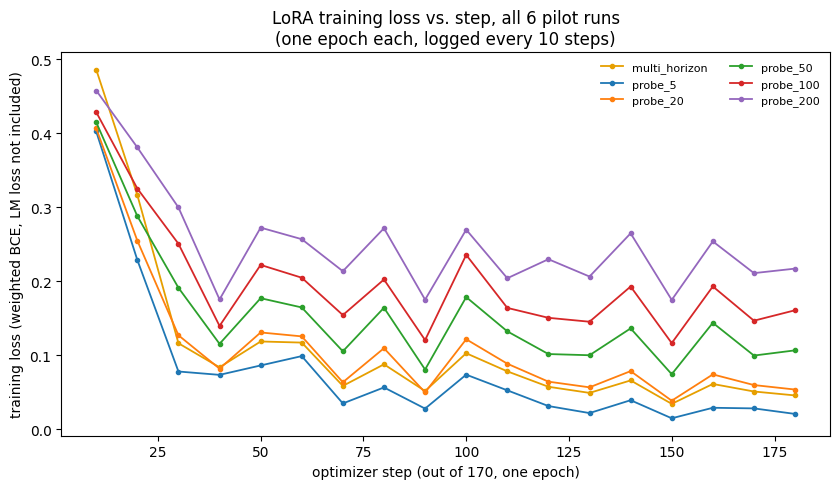

In [12]:
# --- LoRA training loss, all 6 pilot runs (one line per run) ---
id_to_design = {v: ("multi_horizon" if k == "multi_horizon" else f"probe_{k}") for k, v in LORA_PROBE_IDS.items()}
lora_curve_path = TRAINING_CURVES_DIR / "training_curve_lora.csv"
if not lora_curve_path.exists():
    print(f"MISSING: {lora_curve_path} -- source logs: cluster/log/onset-lora-{{multihorizon,probe5,probe20,probe50,probe100,probe200}}-*.log")
else:
    lora_curve_df = pd.read_csv(lora_curve_path)
    fig, ax = plt.subplots(figsize=(8.5, 5))
    for probe_id in lora_curve_df["probe_id"].unique():
        sub = lora_curve_df[lora_curve_df["probe_id"] == probe_id].sort_values("global_step")
        label = id_to_design.get(probe_id, probe_id)
        color = COLOR_LORA_MULTI if "multi_horizon" in probe_id else None
        ax.plot(sub["global_step"], sub["train_loss"], marker="o", markersize=3, linewidth=1.3, label=label, color=color)
    ax.set_xlabel("optimizer step (out of 170, one epoch)")
    ax.set_ylabel("training loss (weighted BCE, LM loss not included)")
    ax.set_title("LoRA training loss vs. step, all 6 pilot runs\n(one epoch each, logged every 10 steps)")
    ax.legend(frameon=False, fontsize=8, ncol=2)
    plt.tight_layout()
    save_fig(fig, "05b_training_curve_lora_all_runs")
    plt.show()

,design,probe_id,global_step,epoch,probe_loss,mean_auc
0,multi_horizon,onset_multi_horizon_lora_pilot_layer16,100,0.589971,0.068417,0.717142
1,multi_horizon,onset_multi_horizon_lora_pilot_layer16,170,1.000000,0.071332,0.789393
8,probe_N,onset_probe_100_lora_pilot_layer16,100,0.589971,0.163510,0.854222
9,probe_N,onset_probe_100_lora_pilot_layer16,170,1.000000,0.165651,0.864021
10,probe_N,onset_probe_200_lora_pilot_layer16,100,0.589971,0.228628,0.851680
11,probe_N,onset_probe_200_lora_pilot_layer16,170,1.000000,0.227222,0.861255
4,probe_N,onset_probe_20_lora_pilot_layer16,100,0.589971,0.077809,0.810831
5,probe_N,onset_probe_20_lora_pilot_layer16,170,1.000000,0.081982,0.854165
6,probe_N,onset_probe_50_lora_pilot_layer16,100,0.589971,0.114661,0.855332
7,probe_N,onset_probe_50_lora_pilot_layer16,170,1.000000,0.118303,0.866829


Saved: /iopsstor/scratch/cscs/mdenegri/degeneration-probe/notebooks/figures/onset_probes/05c_training_curve_lora_val.png
Saved (PDF): /iopsstor/scratch/cscs/mdenegri/degeneration-probe/notebooks/figures/onset_probes/05c_training_curve_lora_val.pdf


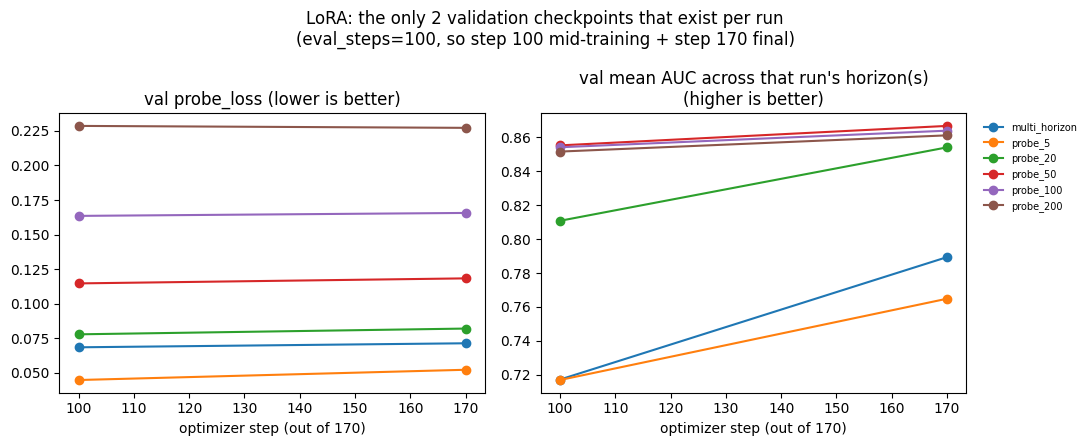

Only 2 points per line because eval_steps=100 and the whole pilot is 170 steps long --
this is a real curve, just a very short one. Not enough to say much about overfitting on its own.


In [13]:
# --- LoRA validation curve: probe_loss and AUC at the 2 points each run was
# evaluated (step 100, mid-training; step 170, the final step) -- read
# directly from each checkpoint's own eval_metrics.jsonl (a real saved
# artifact, unlike the training-loss curve above). ---
lora_eval_curve_rows = []
for design, probe_id in LORA_PROBE_IDS.items():
    p = LOCAL_PROBES_DIR / probe_id / "eval_metrics.jsonl"
    if not p.exists():
        continue
    for line in p.read_text().splitlines():
        rec = json.loads(line)
        prefix = [k.split("/")[0] for k in rec if k.endswith("_auc")][0]
        lora_eval_curve_rows.append({
            "design": "multi_horizon" if design == "multi_horizon" else "probe_N",
            "probe_id": probe_id,
            "global_step": rec["global_step"],
            "epoch": rec["epoch"],
            "probe_loss": rec[f"{prefix}/probe_loss"],
            "mean_auc": np.mean([rec[f"{prefix}/horizon_{h}_auc"] for h in ([design] if design != "multi_horizon" else HORIZONS)]),
        })
lora_eval_curve_df = pd.DataFrame(lora_eval_curve_rows)

if lora_eval_curve_df.empty:
    print("No eval_metrics.jsonl files found for the LoRA checkpoints.")
else:
    display(lora_eval_curve_df.sort_values(["probe_id", "global_step"]))
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for probe_id in lora_eval_curve_df["probe_id"].unique():
        sub = lora_eval_curve_df[lora_eval_curve_df["probe_id"] == probe_id].sort_values("global_step")
        label = id_to_design.get(probe_id, probe_id)
        axes[0].plot(sub["global_step"], sub["probe_loss"], marker="o", label=label)
        axes[1].plot(sub["global_step"], sub["mean_auc"], marker="o", label=label)
    axes[0].set_title("val probe_loss (lower is better)")
    axes[1].set_title("val mean AUC across that run's horizon(s)\n(higher is better)")
    for ax in axes:
        ax.set_xlabel("optimizer step (out of 170)")
    axes[1].legend(frameon=False, fontsize=7, ncol=1, loc="upper left", bbox_to_anchor=(1.02, 1.0))
    fig.suptitle("LoRA: the only 2 validation checkpoints that exist per run\n(eval_steps=100, so step 100 mid-training + step 170 final)")
    plt.tight_layout()
    save_fig(fig, "05c_training_curve_lora_val")
    plt.show()
    print("Only 2 points per line because eval_steps=100 and the whole pilot is 170 steps long --")
    print("this is a real curve, just a very short one. Not enough to say much about overfitting on its own.")

## 10.2 More than AUC: Average Precision and Brier score

AUC (explained in Section 8) only asks "does the probe rank a positive
example above a negative one" - it does not care how many negatives there
are, or how confident the probe actually is. Two more numbers fill in
that gap, and both were already being computed - they just were not shown
in the comparison plots until now.

**Average Precision (AP), in plain words:** imagine sorting every position
by the probe's predicted risk, from highest to lowest, and walking down that
list. AP rewards a probe that puts real positives near the top of that list,
and it gets penalized a lot for every negative example that shows up above a
positive one. A probe that is just randomly guessing gets an AP roughly
equal to the true fraction of positives (which is often well under 1% here) -
so unlike AUC's fixed 0.5 "random" baseline, AP's "random" baseline moves
with how rare the positive class is, and is usually a very small number in
this dataset. That is why AP numbers in this notebook (often 0.01-0.35) look
much lower than the matching AUC numbers (often 0.7-0.9): AUC and AP are
measuring different things, and AP is the more honest one about how rare
true positives are.

**Brier score, in plain words:** for every position, take the probe's
predicted probability (a number between 0 and 1), subtract the true 0/1
label, square the difference, and average that over every position. This
measures *calibration* - not just "does it rank things correctly" but "when
it says 80% likely, is it right about 80% of the time?" Lower is better; 0
is a perfect probe, 0.25 is what a probe saying "50%" for everything would
get.

**An honest gap: Brier score only exists for no-LoRA.** The no-LoRA
evaluation script computes it directly; the shared evaluation code the LoRA
condition uses (`evaluate_probe` in `degeneration_probe/evaluation/evaluate.py`)
never had Brier added to its onset-detection branch. So the Brier plot below
only has a no-LoRA line - there is nothing to compare it against for LoRA
without first extending that shared code.

**A second honest gap: no threshold-based metrics anywhere.** Numbers like
true/false positive counts, precision, recall, or F1 all need picking one
specific cutoff probability first (e.g. "call it a positive prediction above
50%"), and nothing in this pipeline computes those for the onset task, for
either condition. This is not an oversight we are hiding: fixing a
threshold at 50% here could easily mean the probe "never fires", since even
the least rare horizon (200 tokens) has well under 10% true positives at the
token level, and the rarest (5 tokens) has well under 1%. AUC and AP (and
Brier) are all threshold-free, which is exactly why they are what this
notebook reports - adding a properly chosen threshold (e.g. picked from a
precision-recall curve rather than assumed to be 50%) is a reasonable next
step, just not one that has been done yet.

Saved: /iopsstor/scratch/cscs/mdenegri/degeneration-probe/notebooks/figures/onset_probes/05d_noLoRA_ap_vs_layer.png
Saved (PDF): /iopsstor/scratch/cscs/mdenegri/degeneration-probe/notebooks/figures/onset_probes/05d_noLoRA_ap_vs_layer.pdf


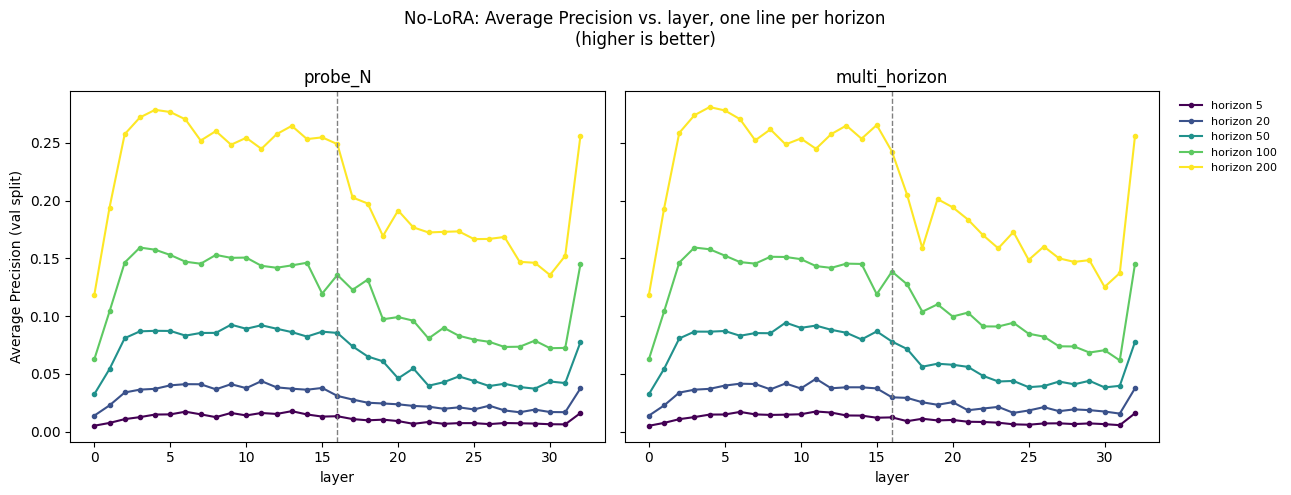

In [14]:
def metric_vs_layer_plot(metric, ylabel, title, fig_name, higher_is_better=True):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
    for ax, design in zip(axes, ["probe_N", "multi_horizon"]):
        sub = val_df[val_df["design"] == design]
        for h in HORIZONS:
            h_sub = sub[sub["horizon"] == h].sort_values("layer")
            ax.plot(h_sub["layer"], h_sub[metric], color=HORIZON_COLORS[h], marker="o", markersize=3, linewidth=1.5, label=f"horizon {h}")
        ax.axvline(LORA_LAYER, color="gray", linewidth=1, linestyle="--")
        ax.set_title(design)
        ax.set_xlabel("layer")
    axes[0].set_ylabel(ylabel)
    axes[1].legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=8)
    fig.suptitle(title + ("\n(higher is better)" if higher_is_better else "\n(lower is better)"))
    plt.tight_layout()
    save_fig(fig, fig_name)
    plt.show()


metric_vs_layer_plot("ap", "Average Precision (val split)", "No-LoRA: Average Precision vs. layer, one line per horizon", "05d_noLoRA_ap_vs_layer")

Saved: /iopsstor/scratch/cscs/mdenegri/degeneration-probe/notebooks/figures/onset_probes/05e_noLoRA_brier_vs_layer.png
Saved (PDF): /iopsstor/scratch/cscs/mdenegri/degeneration-probe/notebooks/figures/onset_probes/05e_noLoRA_brier_vs_layer.pdf


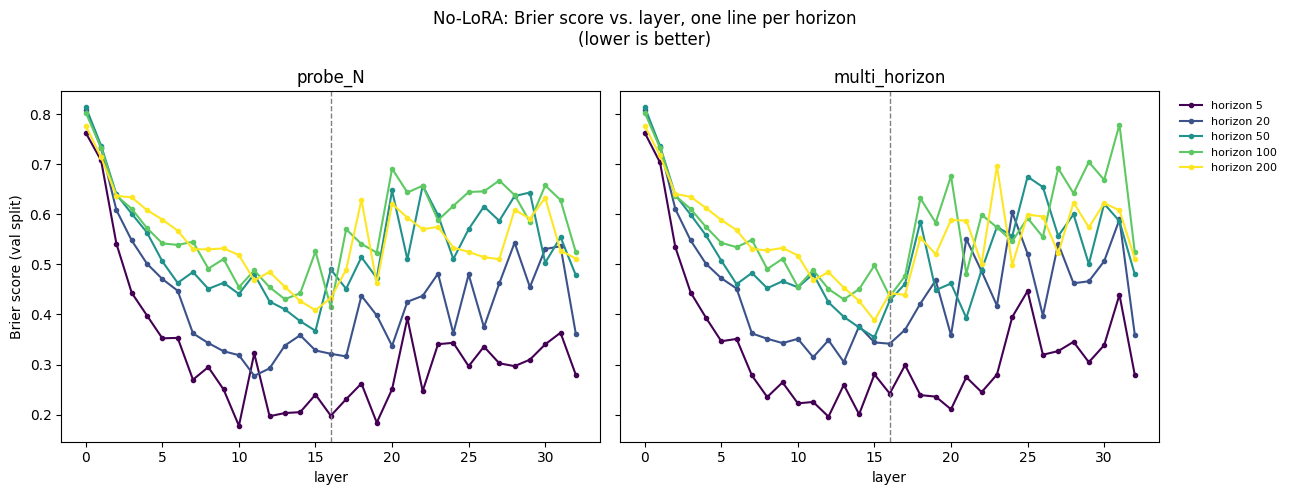

In [15]:
metric_vs_layer_plot("brier", "Brier score (val split)", "No-LoRA: Brier score vs. layer, one line per horizon", "05e_noLoRA_brier_vs_layer", higher_is_better=False)

### 10.3 The main val-split comparison, redone with AP instead of AUC

Same layer-16, no-LoRA-vs-LoRA, both-designs comparison as the next section
below, but scored with AP instead of AUC. Worth looking at side by side with
the AUC version: a design/condition that looks strong on AUC but weak here
is winning mostly by ranking things correctly on average, not by being
useful once you account for how rare true onsets really are.

In [16]:
def condition_comparison_plot(nolora_df, lora_df, split_label, fig_name, metric="auc"):
    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(len(HORIZONS))
    bar_width = 0.2
    combos = [("no-LoRA", "probe_N", -1.5), ("no-LoRA", "multi_horizon", -0.5),
              ("LoRA", "probe_N", 0.5), ("LoRA", "multi_horizon", 1.5)]
    for condition, design, offset in combos:
        src = nolora_df if condition == "no-LoRA" else lora_df
        vals = []
        for h in HORIZONS:
            row = src[(src["design"] == design) & (src["horizon"] == h)]
            vals.append(row[metric].iloc[0] if len(row) else np.nan)
        ax.bar(x + offset * bar_width, vals, width=bar_width, color=CONDITION_DESIGN_COLORS[(condition, design)],
               label=f"{condition} / {design}")
    ax.set_xticks(x)
    ax.set_xticklabels(HORIZONS)
    if metric == "auc":
        ax.axhline(0.5, color="black", linewidth=0.8, linestyle=":")
    ax.set_xlabel("horizon (tokens)")
    ax.set_ylabel(metric.upper() if metric == "auc" else metric.upper())
    ax.set_title(f"Layer 16: no-LoRA vs LoRA, both designs -- {split_label} ({metric.upper()})")
    ax.legend(frameon=False, ncol=2, fontsize=8)
    plt.tight_layout()
    save_fig(fig, fig_name)
    plt.show()

In [17]:
def load_lora_val_metrics():
    rows = []
    for design, probe_id in LORA_PROBE_IDS.items():
        eval_path = LOCAL_PROBES_DIR / probe_id / "evaluation_results.json"
        if not eval_path.exists():
            continue
        metrics = json.loads(eval_path.read_text())
        prefix = [k.split("/")[0] for k in metrics if k.endswith("_auc")][0]
        horizons_here = [5, 20, 50, 100, 200] if design == "multi_horizon" else [design]
        for h in horizons_here:
            rows.append({
                "layer": LORA_LAYER, "split": "val", "horizon": h,
                "design": "multi_horizon" if design == "multi_horizon" else "probe_N",
                "auc": metrics[f"{prefix}/horizon_{h}_auc"], "ap": metrics[f"{prefix}/horizon_{h}_ap"],
                "n": metrics[f"{prefix}/horizon_{h}_n"], "n_pos": metrics[f"{prefix}/horizon_{h}_n_pos"],
            })
    return pd.DataFrame(rows)


lora_val_df = load_lora_val_metrics()
display(lora_val_df)

,layer,split,horizon,design,auc,ap,n,n_pos
0,16,val,5,multi_horizon,0.796180,0.017635,314206,645
1,16,val,20,multi_horizon,0.778617,0.033167,314206,2222
2,16,val,50,multi_horizon,0.786621,0.070855,314206,5297
3,16,val,100,multi_horizon,0.790247,0.121091,314206,10274
4,16,val,200,multi_horizon,0.795299,0.196930,314206,19787
5,16,val,5,probe_N,0.764844,0.017480,314206,645
6,16,val,20,probe_N,0.854165,0.060491,314206,2222
7,16,val,50,probe_N,0.866829,0.125861,314206,5297
8,16,val,100,probe_N,0.864021,0.219769,314206,10274
9,16,val,200,probe_N,0.861255,0.347952,314206,19787


Saved: /iopsstor/scratch/cscs/mdenegri/degeneration-probe/notebooks/figures/onset_probes/05f_LoRA_vs_noLoRA_val_AP.png
Saved (PDF): /iopsstor/scratch/cscs/mdenegri/degeneration-probe/notebooks/figures/onset_probes/05f_LoRA_vs_noLoRA_val_AP.pdf


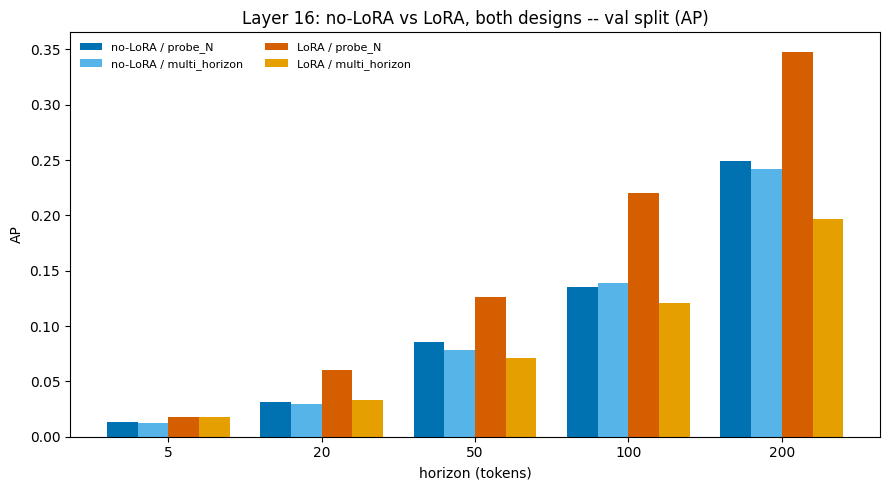

In [18]:
condition_comparison_plot(layer16_df[layer16_df["split"] == "val"], lora_val_df, "val split", "05f_LoRA_vs_noLoRA_val_AP", metric="ap")

## 11. The main comparison: does LoRA help?

This is the key question this notebook was built to answer. We compare, at
the one layer both conditions share (layer 16):

- no-LoRA `probe_N` vs no-LoRA `multi_horizon` (already shown above)
- LoRA `probe_N` vs LoRA `multi_horizon`
- no-LoRA vs LoRA, for each design

Reminder of an important caveat: the LoRA pilot is a **single training
pass** over the data, at **one layer only**, while every no-LoRA probe here
had a full, dedicated training run at that same layer. So this is an early
signal, not a final verdict - see the summary at the end for what a fair
follow-up would need.

,layer,split,horizon,design,auc,ap,n,n_pos
0,16,val,5,multi_horizon,0.796180,0.017635,314206,645
1,16,val,20,multi_horizon,0.778617,0.033167,314206,2222
2,16,val,50,multi_horizon,0.786621,0.070855,314206,5297
3,16,val,100,multi_horizon,0.790247,0.121091,314206,10274
4,16,val,200,multi_horizon,0.795299,0.196930,314206,19787
5,16,val,5,probe_N,0.764844,0.017480,314206,645
6,16,val,20,probe_N,0.854165,0.060491,314206,2222
7,16,val,50,probe_N,0.866829,0.125861,314206,5297
8,16,val,100,probe_N,0.864021,0.219769,314206,10274
9,16,val,200,probe_N,0.861255,0.347952,314206,19787


Saved: /iopsstor/scratch/cscs/mdenegri/degeneration-probe/notebooks/figures/onset_probes/06_LoRA_vs_noLoRA_val.png
Saved (PDF): /iopsstor/scratch/cscs/mdenegri/degeneration-probe/notebooks/figures/onset_probes/06_LoRA_vs_noLoRA_val.pdf


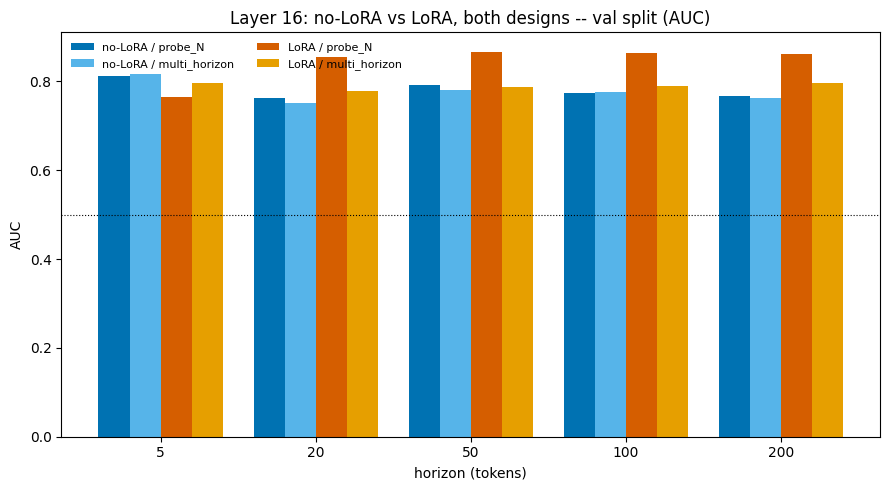

In [19]:
# lora_val_df and condition_comparison_plot were already loaded/defined in Section 10.3.
display(lora_val_df)
condition_comparison_plot(layer16_df[layer16_df["split"] == "val"], lora_val_df, "val split", "06_LoRA_vs_noLoRA_val")

### 11.1 Same comparison on `test_indomain` / `test_heldout_domains`

The block below only produces a plot if the extra LoRA evaluation files
(`eval_extra_splits.parquet`, Section 5) are present. If you see a message
instead of a plot, run the command Section 5 printed and re-run this cell.

,probe_id,layer,split,horizon,design,auc,ap,n,n_pos,n_rollouts,n_rollouts_pos
0,onset_multi_horizon_lora_pilot_layer16,16,test_indomain,5,multi_horizon,0.822038,0.010158,377747,780,599,133
1,onset_multi_horizon_lora_pilot_layer16,16,test_indomain,20,multi_horizon,0.805345,0.028556,377747,2703,599,133
2,onset_multi_horizon_lora_pilot_layer16,16,test_indomain,50,multi_horizon,0.806016,0.066594,377747,6440,599,133
3,onset_multi_horizon_lora_pilot_layer16,16,test_indomain,100,multi_horizon,0.801325,0.112437,377747,12426,599,133
4,onset_multi_horizon_lora_pilot_layer16,16,test_indomain,200,multi_horizon,0.801250,0.213239,377747,24011,599,133


Saved: /iopsstor/scratch/cscs/mdenegri/degeneration-probe/notebooks/figures/onset_probes/06_LoRA_vs_noLoRA_test_indomain.png
Saved (PDF): /iopsstor/scratch/cscs/mdenegri/degeneration-probe/notebooks/figures/onset_probes/06_LoRA_vs_noLoRA_test_indomain.pdf


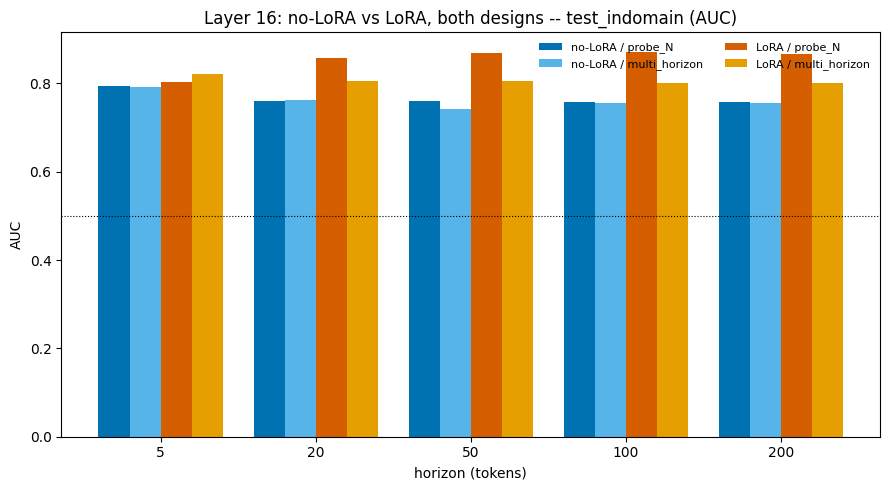

Saved: /iopsstor/scratch/cscs/mdenegri/degeneration-probe/notebooks/figures/onset_probes/06_LoRA_vs_noLoRA_test_heldout_domains.png
Saved (PDF): /iopsstor/scratch/cscs/mdenegri/degeneration-probe/notebooks/figures/onset_probes/06_LoRA_vs_noLoRA_test_heldout_domains.pdf


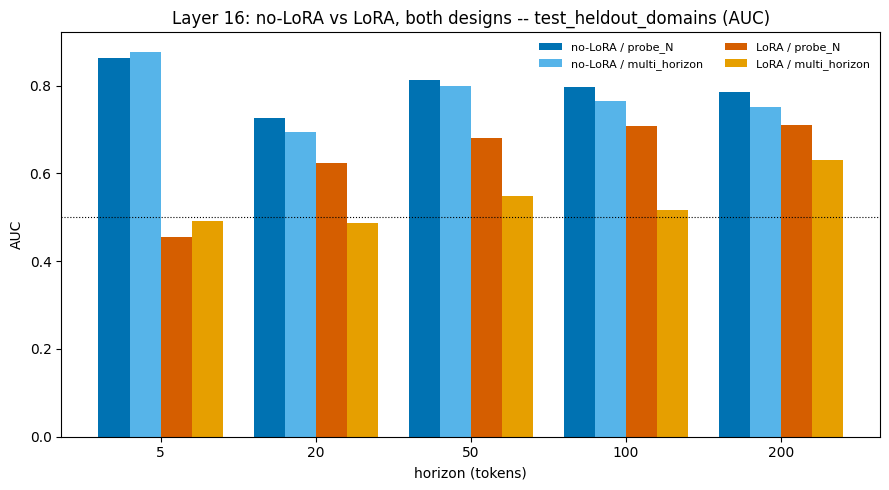

In [20]:
def load_lora_extra_metrics():
    frames = []
    for design, probe_id in LORA_PROBE_IDS.items():
        p = LOCAL_PROBES_DIR / probe_id / "eval_extra_splits.parquet"
        if p.exists():
            frames.append(pd.read_parquet(p))
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


lora_extra_df = load_lora_extra_metrics()
if lora_extra_df.empty:
    print("No eval_extra_splits.parquet files found yet -- see Section 5 for the command to build them.")
else:
    display(lora_extra_df.head())
    for split in ["test_indomain", "test_heldout_domains"]:
        lora_split_df = lora_extra_df[lora_extra_df["split"] == split]
        nolora_split_df = layer16_df[layer16_df["split"] == split]
        if lora_split_df.empty:
            print(f"No LoRA results yet for split={split}.")
            continue
        condition_comparison_plot(nolora_split_df, lora_split_df, split, f"06_LoRA_vs_noLoRA_{split}")

## 12. Summary table

One table with every number from the main comparison above (layer 16, all
three splits, both conditions, both designs), so it can be scanned or
copied out directly. `brier` is blank for every LoRA row - see Section 10.2
for why (it was only ever computed for the no-LoRA evaluation code).

In [21]:
SUMMARY_COLS = ["condition", "split", "design", "horizon", "auc", "ap", "brier", "n_pos"]
summary_frames = [layer16_df.assign(condition="no-LoRA")[SUMMARY_COLS]]
summary_frames.append(lora_val_df.assign(condition="LoRA", brier=np.nan)[SUMMARY_COLS])
if not lora_extra_df.empty:
    summary_frames.append(lora_extra_df.assign(condition="LoRA", brier=np.nan)[SUMMARY_COLS])
summary_df = pd.concat(summary_frames, ignore_index=True).sort_values(["split", "horizon", "design", "condition"])
display(summary_df.reset_index(drop=True))
summary_path = FIGURES_DIR / "onset_probes_summary.csv"
summary_df.to_csv(summary_path, index=False)
print(f"Saved summary table: {summary_path}")

,condition,split,design,horizon,auc,ap,brier,n_pos
0,LoRA,test_heldout_domains,multi_horizon,5,0.490911,0.003055,NaN,66
1,no-LoRA,test_heldout_domains,multi_horizon,5,0.877520,0.002412,0.134342,66
2,LoRA,test_heldout_domains,probe_N,5,0.454136,0.002803,NaN,66
3,no-LoRA,test_heldout_domains,probe_N,5,0.862537,0.002512,0.128101,66
4,LoRA,test_heldout_domains,multi_horizon,20,0.486452,0.010167,NaN,231
5,no-LoRA,test_heldout_domains,multi_horizon,20,0.693993,0.002137,0.363196,231
6,LoRA,test_heldout_domains,probe_N,20,0.623627,0.021261,NaN,231
7,no-LoRA,test_heldout_domains,probe_N,20,0.726247,0.002862,0.281594,231
8,LoRA,test_heldout_domains,multi_horizon,50,0.547922,0.031468,NaN,561
9,no-LoRA,test_heldout_domains,multi_horizon,50,0.798793,0.010031,0.341550,561


Saved summary table: /iopsstor/scratch/cscs/mdenegri/degeneration-probe/notebooks/figures/onset_probes/onset_probes_summary.csv


## 13. Take-aways, in plain words

Fill this in together after looking at the plots above -- a few starting
points from the numbers as of when this notebook was last run:

- No-LoRA results are strongest around the middle layers (roughly layers
  10-20 out of 33); very early and very late layers are noticeably worse at
  every horizon.
- Layer 16 (the LoRA pilot's layer) is a solid, but not always the single
  best, no-LoRA layer -- see Section 8's ranking table.
- On `val` and `test_indomain`, the LoRA pilot's `probe_N` heads score
  clearly higher AUC than their no-LoRA counterparts at horizons 20 and
  above, but *lower* at horizon 5. `multi_horizon` improves more mildly and
  consistently across every horizon under LoRA on these two splits.
- **But on `test_heldout_domains` (Section 11.1), that flips: LoRA is
  *worse* than no-LoRA at every single horizon, for both designs.** No-LoRA
  stays in the high 0.7s / low 0.8s AUC range there, same as on the other
  splits, while LoRA drops as low as ~0.45-0.55 for the shorter horizons.
  This lines up with a plausible story: letting the LM's own weights shift
  (LoRA) can fit the pilot's training/val prompt domains well, but that fit
  may not carry over to genuinely new domains, whereas the frozen model's
  activations do not have this failure mode because the model itself never
  changed. This is only one epoch at one layer, so it needs a second layer
  and/or a second epoch to confirm it is a real effect and not a fluke - but
  the fact that it is consistent across all 5 horizons and both designs
  makes it unlikely to be pure noise.
- The nesting check (Section 10) shows both designs get noticeably less
  consistent the further apart two horizons are: comparing horizon 5 to 20
  disagrees on roughly 15-20% of tokens, but comparing horizon 50 to 100 or
  100 to 200 disagrees on 40-58% of tokens. `multi_horizon` being trained
  jointly does not clearly fix this on its own.
- `test_heldout_domains` numbers (11 positive rollouts total) should be read
  as a rough direction, not a precise score, for either condition - but see
  the point above, the LoRA-vs-no-LoRA gap there is large and consistent
  enough to be worth a closer look regardless.

**What a fair, fuller LoRA-vs-no-LoRA comparison would still need:**
- More than one training epoch for the LoRA pilot (the no-LoRA probes had a
  dedicated training run per layer; the LoRA pilot had one epoch, shared
  across the whole model).
- LoRA runs at more than one layer, so the comparison is not anchored to a
  single, possibly-lucky layer choice.
- The `test_indomain` / `test_heldout_domains` LoRA numbers from Section
  11.1, if they were not yet available when this notebook was generated.
- Thresholded metrics (precision/recall/F1 at a chosen operating point,
  Section 10.2) and a Brier score for the LoRA condition, if a fair
  side-by-side on those is wanted too.

## 14. How to reproduce every step

All commands assume you are at the repo root (`$REPO`), with the project's
virtualenv activated. Cluster (`sbatch`) commands submit a job and return
immediately; check progress with `sacct -j <job_id> --format=State,ExitCode -X`.

| Step | What it does | Command |
|---|---|---|
| A | Build onset labels (positive/negative rollouts, onset position, per-horizon labels) | `python -m degeneration_probe.dataset_gen.onset_labels --config configs/dataset/degeneration-dataset-apertus-8b-instruct.yaml` |
| C | Quick per-layer, per-horizon logistic-regression sweep | `sbatch cluster/layer_sweep.sbatch` |
| D+E | Train all 198 no-LoRA probes (33 layers x [5 `probe_N` + 1 `multi_horizon`]) | `sbatch cluster/train_onset_probes.sbatch` (array job, one task per layer) |
| F | Score every no-LoRA probe on val / test_indomain / test_heldout_domains | `sbatch cluster/evaluate_onset_probes.sbatch` (array job, one task per layer) |
| I | Train the LoRA multi_horizon pilot (layer 16, all 5 horizons) | `sbatch cluster/train_onset_lora_full.sbatch "5 20 50 100 200"` |
| J | Train one LoRA probe_N pilot (layer 16, single horizon `N`) | `sbatch cluster/train_onset_lora_full.sbatch "N"` |
| K (this notebook's new piece) | Score a LoRA checkpoint on test_indomain / test_heldout_domains | `sbatch cluster/evaluate_onset_lora_probes.sbatch <probe_id>` |
| Section 10.1's training curves | Re-extract the training-loss curves from SLURM job logs into the small CSVs this notebook reads (only needed if those CSVs are missing/stale - the logs themselves are gitignored and not guaranteed to stick around) | one-off script, not part of the regular pipeline - re-parse `cluster/log/onset-probe-train-*_16.log` (no-LoRA) and `cluster/log/onset-lora-{multihorizon,probe5,probe20,probe50,probe100,probe200}-*.log` (LoRA) the same way this notebook's `training_curve_nolora_layer16.csv` / `training_curve_lora.csv` were built |
| This notebook | Regenerate every plot/table above | Run all cells in `notebooks/inspect_onset_probes.ipynb` |

Every plot in this notebook is also written to
`notebooks/figures/onset_probes/` as both `.png` and `.pdf` files, with the
exact path printed under each plot when it is made (that whole folder is
gitignored, since it is generated output, not source). The two training-curve
CSVs behind Section 10.1 (`training_curve_nolora_layer16.csv`,
`training_curve_lora.csv`) live in `notebooks/training_curves/` instead, and
*are* committed to the repo, since the SLURM logs they were extracted from
are not.